In [2]:
import numpy as np
import torch
import mogptk
from sklearn.datasets import make_classification, make_regression

torch.manual_seed(1);

(<Figure size 1200x1200 with 3 Axes>,
 array([[<Axes: xlabel='X', ylabel='Y'>],
        [<Axes: xlabel='X', ylabel='Y'>],
        [<Axes: xlabel='X', ylabel='Y'>]], dtype=object))

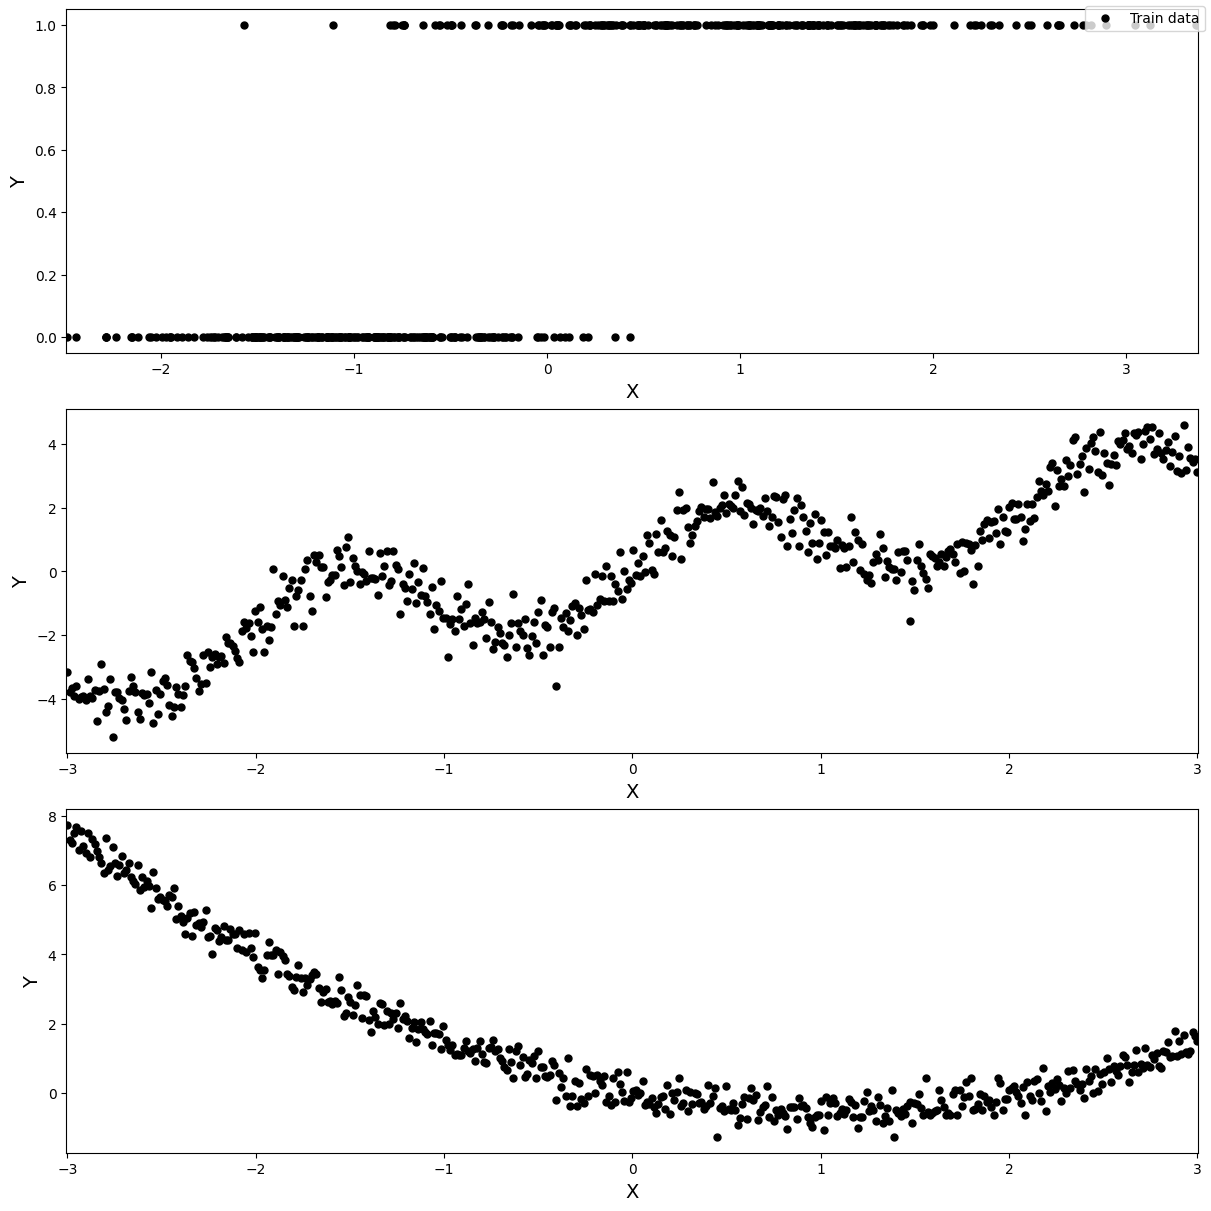

In [3]:
n = 500

# Salida 1
X1, y1 = make_classification(
    n_samples=n,
    n_features=1,
    n_informative=1,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=1
)

X1 = X1.reshape(-1, 1)
y1 = y1.reshape(-1, 1)

# Salida 2
X2 = np.linspace(-3.0, 3.0, n).reshape(-1, 1)
y2 = X2 + 1.5 * np.sin(3.0 * X2) + 0.5*np.random.randn(n, 1)

# Salida 3
X3 = np.linspace(-3.0, 3.0, n).reshape(-1, 1)
y3 = 0.5 * X3**2 - X3 + 0.3 * np.random.randn(n, 1)

# Dataset multioutput (D = 3)
data = mogptk.DataSet(
    mogptk.Data(X1, y1),
    mogptk.Data(X2, y2),
    mogptk.Data(X3, y3),
)

data.plot()


In [4]:
# Two latent processes (Q = 2)
k1 = mogptk.gpr.SquaredExponentialKernel()
k2 = mogptk.gpr.SquaredExponentialKernel()
# Linear Model of Coregionalization
kernel = mogptk.gpr.LinearModelOfCoregionalizationKernel(
    k1,
    k2,
    output_dims=3   # D = 3 salidas
)

In [5]:
likelihood = mogptk.gpr.MultiOutputLikelihood(
    mogptk.gpr.BernoulliLikelihood(),
     mogptk.gpr.StudentTLikelihood(),
    mogptk.gpr.StudentTLikelihood(),
)

In [6]:
inference = mogptk.Hensman(likelihood=likelihood)

In [ ]:
model = mogptk.Model(data, kernel, inference=inference)

Starting optimization using Adam
‣ Model: Hensman
  ‣ Kernel: LinearModelOfCoregionalizationKernel[SquaredExponentialKernel,SquaredExponentialKernel]
  ‣ Likelihood: [BernoulliLikelihood,StudentTLikelihood,StudentTLikelihood]
‣ Channels: 3
‣ Parameters: 1127262
‣ Training points: 1500
‣ Iterations: 1000
   500/1500   0:00:00  loss=     1824.27  error=     117.182
   527/1500   0:00:10  loss=     1812.86  error=       113.7
   555/1500   0:00:20  loss=     1800.44  error=     112.052
   582/1500   0:00:30  loss=      1791.5  error=     109.426
   609/1500   0:00:40  loss=     1784.31  error=     107.135
   637/1500   0:00:50  loss=     1778.21  error=     105.284
   664/1500   0:01:00  loss=      1773.3  error=     103.714
   691/1500   0:01:10  loss=     1769.04  error=     102.469
   718/1500   0:01:20  loss=     1765.53  error=      100.85
   745/1500   0:01:30  loss=     1761.93  error=     100.791
   772/1500   0:01:40  loss=     1758.98  error=     99.9321
   799/1500   0:01:50  l

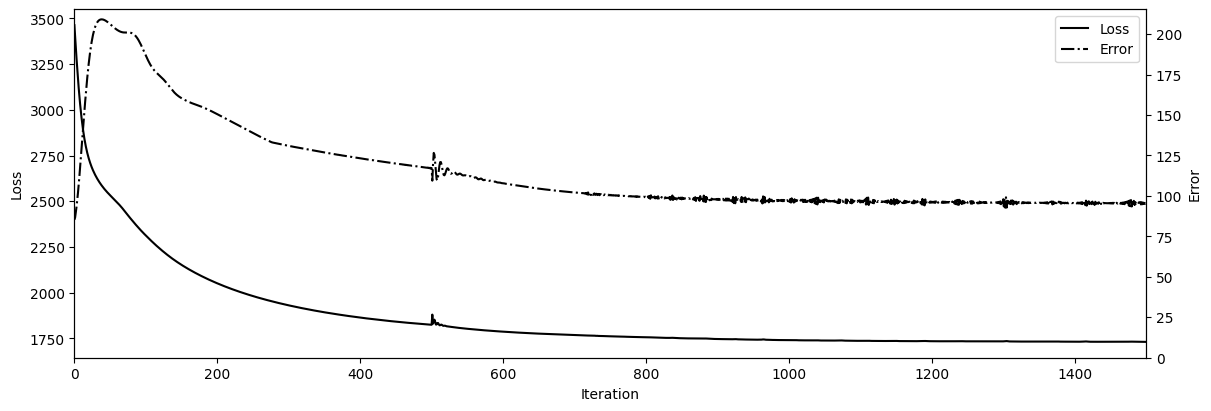

In [14]:
model.train(iters=1000, verbose=True, error='mape', lr=0.02)
model.plot_losses();

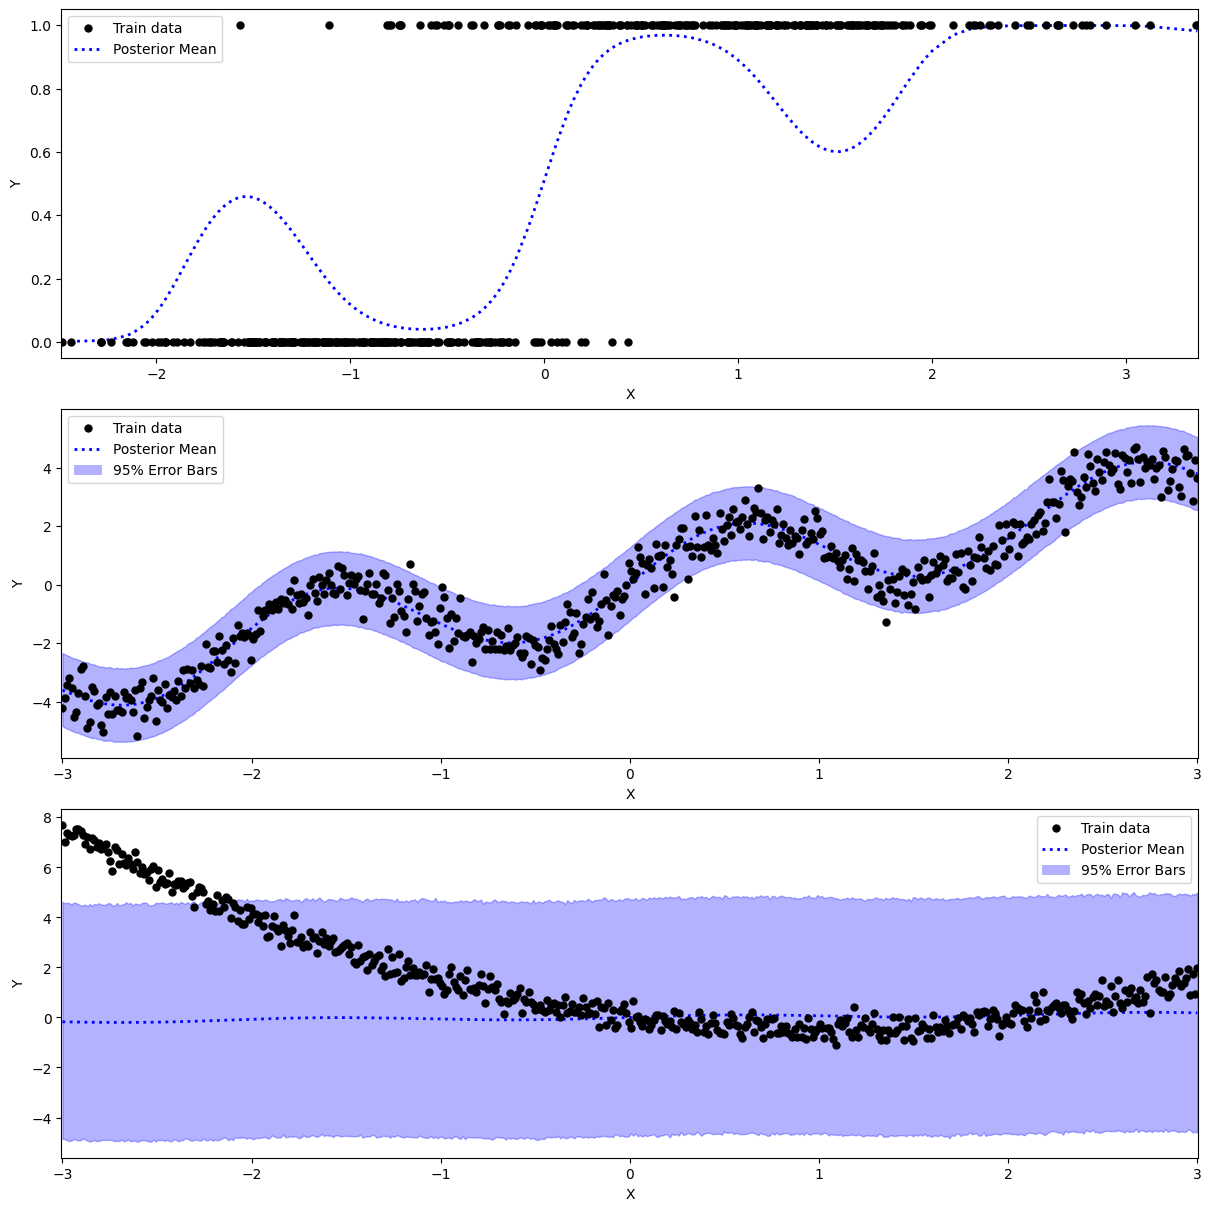

In [15]:
model.plot_prediction(n=100000);